<a href="https://colab.research.google.com/github/JasminAcostaMendez26/Estad-stica-Verano/blob/main/PROYECTO_UNIDAD_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




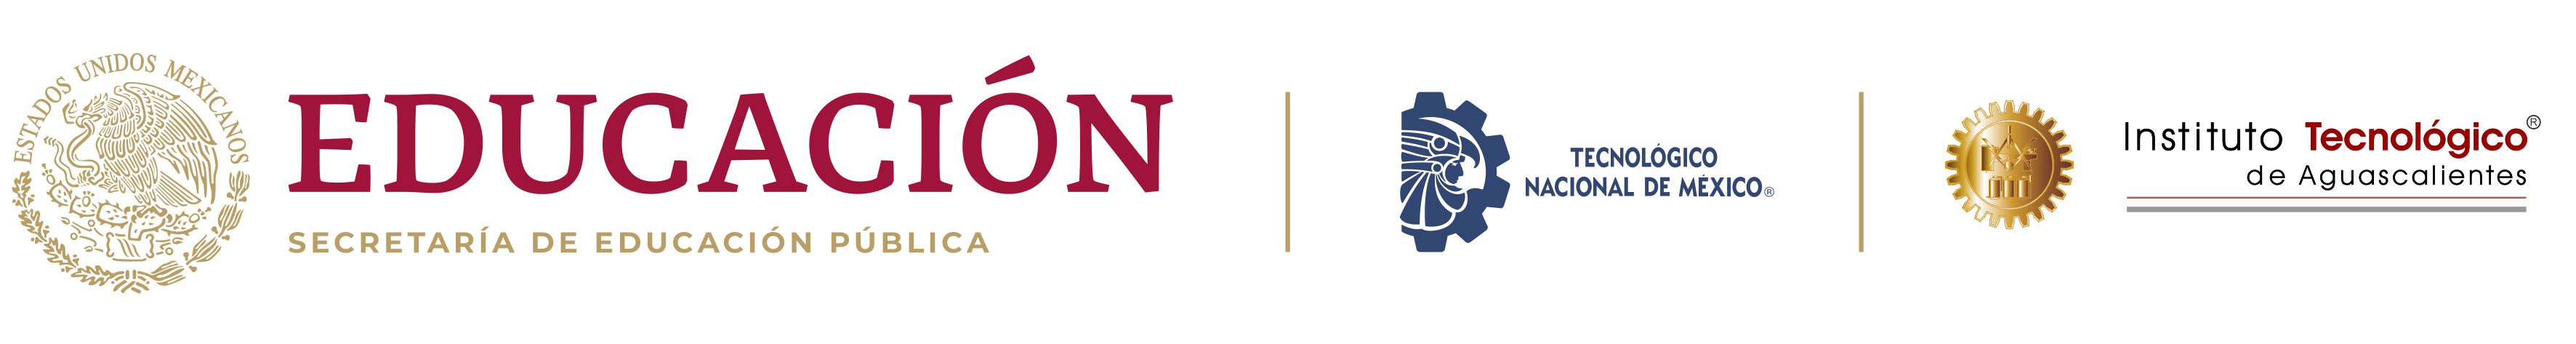

          
          
          
          
           #TECNOLÓGICO NACIONAL DE MÉXICO CAMPUS AGUASCALIENTES

                  Asignatura: Estadistica Inferencial 2

                        Grupo: GEG0908 V044

               Carrera: Ingeniería en Gestión Empresarial

                Nombre del docente: Jose Cruz Muñoz Esparza

                Nombre del alumno: Alondra Jasmin Acosta Mendez

                         No. De Control: 22150432


In [1]:
import pandas as pd
df= pd.read_csv("https://raw.githubusercontent.com/JasminAcostaMendez26/Estad-stica-Verano/refs/heads/main/aug_test.csv")
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2124,1289,city_103,0.920,Male,No relevent experience,no_enrollment,Graduate,Humanities,16,NaN,Public Sector,4,15
2125,195,city_136,0.897,Male,Has relevent experience,no_enrollment,Masters,STEM,18,NaN,NaN,2,30
2126,31762,city_100,0.887,Male,No relevent experience,no_enrollment,Primary School,NaN,3,NaN,Pvt Ltd,never,18
2127,7873,city_102,0.804,Male,Has relevent experience,Full time course,High School,NaN,7,100-500,Public Sector,1,84


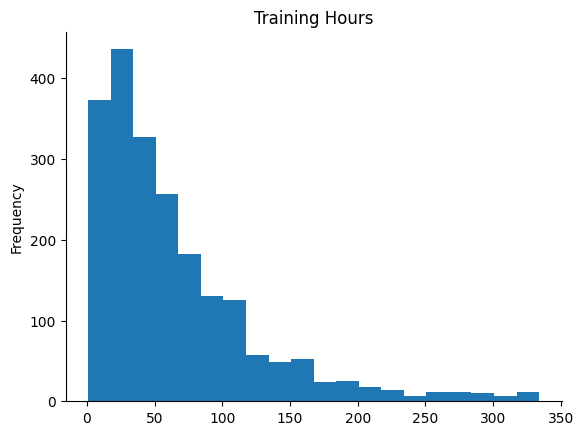

In [3]:
from matplotlib import pyplot as plt
df['training_hours'].plot(kind='hist', bins=20, title='Training Hours')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [5]:
from statsmodels.formula.api import ols
import statsmodels.api as sm
modelo_lineal=ols("training_hours ~ C(gender)", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
#if valor_p_psh<0.05:
 # print("Ho: No hay relacion entre X y Y")
#else:
 # print("H1: Si hay relacion entre X y Y")
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
C(gender),2.0,7.505883e+03,3752.941328,1.00893,0.364838
Residual,1618.0,6.018513e+06,3719.723661,NaN,NaN


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Female   Male   4.0226 0.7408  -8.7616 16.8068  False
Female  Other  18.9002 0.3409 -12.7593 50.5598  False
  Male  Other  14.8776 0.4621 -14.5661 44.3214  False
-----------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

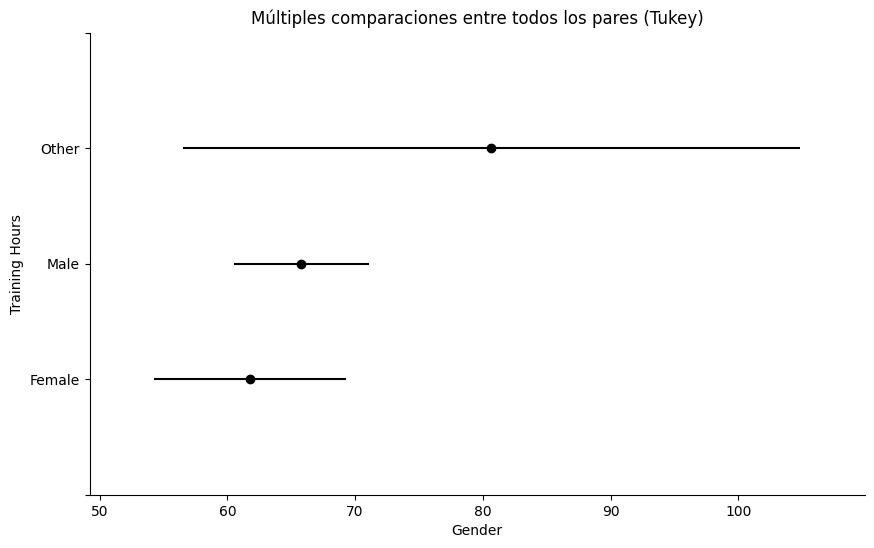

In [9]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Remove rows with missing values in 'gender' or 'training_hours'
df_cleaned = df.dropna(subset=['gender', 'training_hours'])

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df_cleaned['training_hours'], groups=df_cleaned['gender'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Training Hours", xlabel="Gender")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3

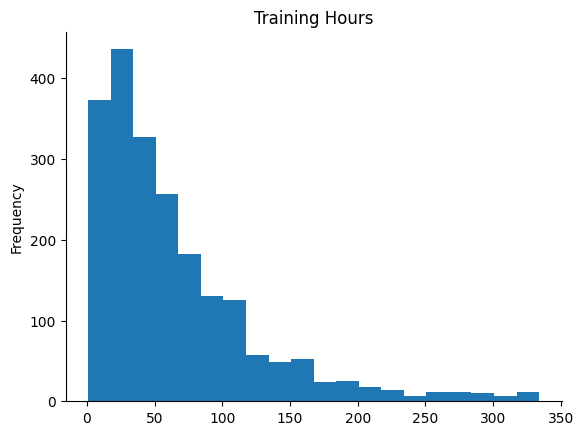

In [19]:
from matplotlib import pyplot as plt
df['training_hours'].plot(kind='hist', bins=20, title='Training Hours')
plt.gca().spines[['top', 'right',]].set_visible(False)

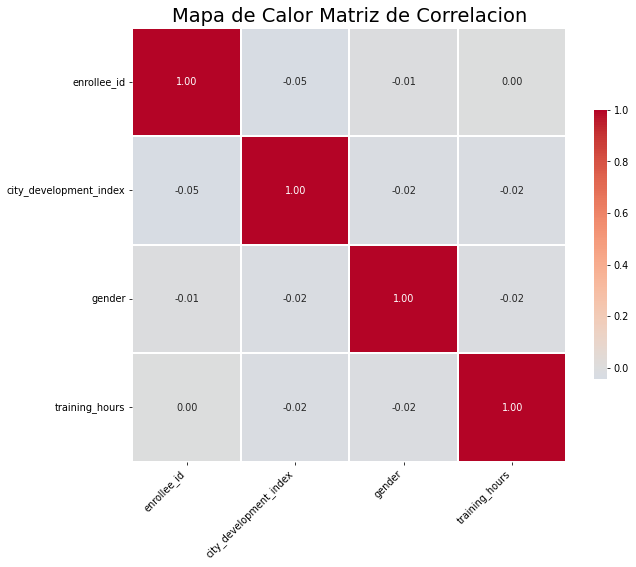

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
matriz_de_correlacion=df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(10,10),dpi=70)
sns.heatmap(matriz_de_correlacion, #lo que va a grafica
    annot=True,#se muestran los valores en las celdas
    fmt="0.2f", #0.2f significa 2 decimales
    cmap="coolwarm", #paleta de colroes
    square=True,#forzar cuadrado
    linewidths=0.5,#grosor de lineas
    cbar_kws={"shrink":0.5}, #tama;o de barra lateral
    center=0, #linea vertical central
)
plt.title("Mapa de Calor Matriz de Correlacion",fontsize=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

      enrollee_id      city  city_development_index  gender  \
0           32403   city_41                   0.827     0.0   
1            9858  city_103                   0.920     1.0   
2           31806   city_21                   0.624     0.0   
3           27385   city_13                   0.827     0.0   
4           27724  city_103                   0.920     0.0   
...           ...       ...                     ...     ...   
2124         1289  city_103                   0.920     0.0   
2125          195  city_136                   0.897     0.0   
2126        31762  city_100                   0.887     0.0   
2127         7873  city_102                   0.804     0.0   
2128        12215  city_102                   0.804     0.0   

          relevent_experience enrolled_university education_level  \
0     Has relevent experience    Full time course        Graduate   
1     Has relevent experience       no_enrollment        Graduate   
2      No relevent experience       

,df,sum_sq,mean_sq,F,PR(>F)
city_development_index,1.0,3.962514e+03,3962.513901,1.092041,0.296138
Residual,2127.0,7.717903e+06,3628.539200,NaN,NaN


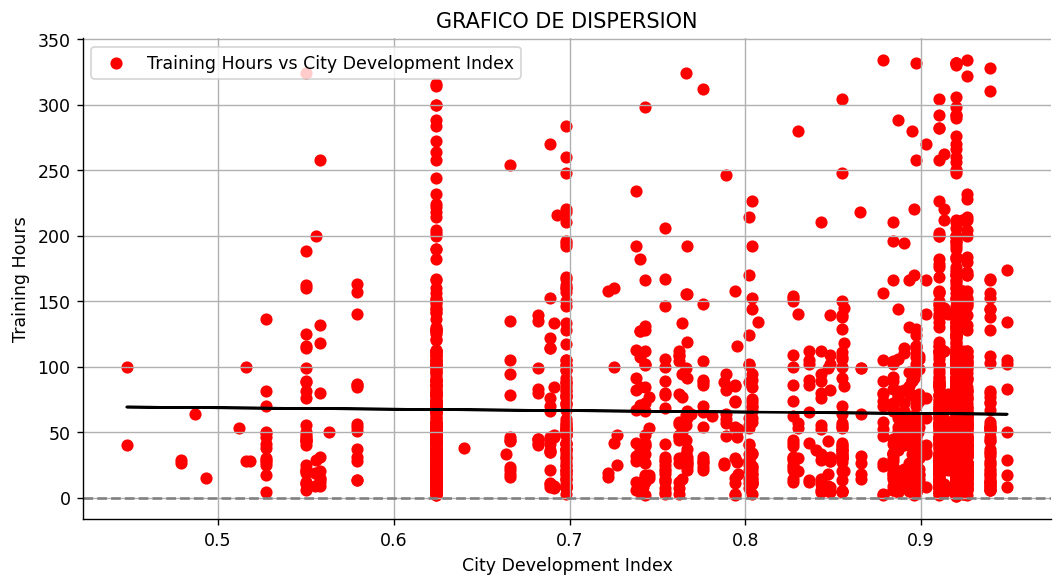

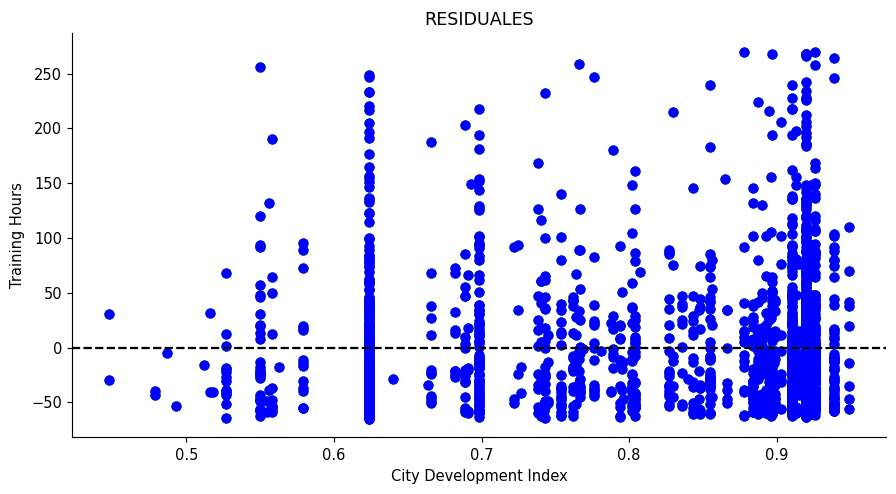

In [23]:
x=df["city_development_index"]
y=df["training_hours"]
df.head(10)
print(df)
print("\n")

#REALIZAR UN DIAGRAMA DE DISPERSION PARA LOS DATOS
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5),dpi=125)
plt.scatter(x,y,
    label="Training Hours vs City Development Index",
    color="RED")
plt.title("GRAFICO DE DISPERSION")
plt.xlabel("City Development Index")
plt.ylabel("Training Hours")
plt.axhline(y=0, color="GREY", linestyle="--")
plt.legend()
plt.grid()
df.head()
plt.gca().spines[["top","right"]].set_visible(False)

#3.- LOS DATOS SOPORTAN LA SUPOSICION DE LIENALIDAD
#NO

#4.- CALCULAR EL COEFICIENTE DE CORRELACION
from scipy.stats import pearsonr
r,_=pearsonr(x,y)
print( f"COEFICIENTE DE CORRELACION: {r: 0.4f}\n")

#6.- OBTENGA LA RECTA DE REGRESION AJUSTADA Y GRAFICAR SOBRE EL GRAFICO DE
#DISPERSION
import statsmodels.api as sm
x_constante=sm.add_constant(x)
modelo=sm.OLS(y,x_constante).fit()
yc=modelo.predict(x_constante)
plt.plot(x,yc, color="BLACK")

#5.- CALCULE EL COEFICIENTE DE DETERMINACION E INTERPRETE EL RESULTADO
from sklearn.metrics import r2_score
r2=r2_score(y,yc)
print( f"COEFICIENTE DE DETERMINACION: {r2: 0.4f} \n")

#7.-OBTENGA UN INTERVALO DE CONFIANZA DEL 95% PARA LA PENDIENTE DE LA RECTA DE
nivel_confianza= 0.95
intervalo_de_confianza=modelo.conf_int(alpha= 1 - nivel_confianza)
intervalo_de_confianza_b1=intervalo_de_confianza.iloc[1]
print(f"INTERVALO DE CONFIANZA DEL PARA b1 ES: {nivel_confianza:0.0%} \n")
print(f"{intervalo_de_confianza_b1[0]: 0.4f} < b1 < {intervalo_de_confianza_b1[1]: 0.4f} \n")

#8.- CALCULE LOS RESIDUALES Y TRACE UN NUEVO GRAFICO DE DISPERSION. COMENTE,
# PARECE QUE SE VERIFICAN LOS SUPUESTOS
residuales= modelo.resid
plt.figure(figsize=(10,5),dpi=105)
plt.scatter(x,residuales, color="Green")
plt.title("RESIDUALES")
plt.xlabel("City Development Index")
plt.ylabel("Training Hours")
plt.axhline(y=0, color="grey", linestyle="--")
plt.scatter(x, residuales,
            label="City Development Index",
            color="BLUE")
plt.axhline(y=0, color="BLACK", linestyle="--")
plt.gca().spines[["top","right"]].set_visible(False)

#9.- REALIZAR LA PRUEBA DE SHAPIRO PARA LOS RESIDUALES Y COMENTE EL RESULTADO
from scipy.stats import shapiro
estadistico_shapiro, valor_p_sh = shapiro(residuales)
print("valor_p_sh:", valor_p_sh )
print("\n")
if valor_p_sh<0.05:
  print("Los datos no siguen una distribucion normal")
else:
  print("Los datos siguen una distribucion normal \n")

#10.-REALIZAR LA PRUEBA DE BREUSCHPAGAN PARA LOS RESIDUALES Y COMENTE LOS RESULTADOS
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print("valor_p_bp:", valor_p_bp)
print("\n")
if valor_p_bp<0.05:
  print("Hay heteroscedasticidad")
else:
  print("Hay homosedasticidad \n")

#11.- UTILIZA LA RECTA DE REGRESION PARA INTERPOLAR DOS VALORES Y EXTRAPOLAR UNO
#COMENTA LOS RESULTADOS
#print(f"Para x = 5, y = {modelo.predict([1,5])[0]}")
#print(f"Para x = 8, y = {modelo.predict([1,8])[0]}")
#print(f"Para x = 20, y = {modelo.predict([1,20])[0]}\n")\

#12.- REALIZAR TABLA ANOVA E INTERPRETAR EL RESULTADO
from statsmodels.formula.api import ols
modelo_lineal=ols(" training_hours ~ city_development_index", data=df).fit()
tabla_anova=sm.stats.anova_lm(modelo_lineal)
if valor_p_bp<0.05:
  print("No hay relacion entre X y Y")
else:
  print("Si hay relacion entre X y Y")
tabla_anova